# BCS Data Analysis Project

I've created tools that will allow us to do this automatically, but they will need inputs

In [1]:
# BCS 25/26 Event locations
# These must manually be extracted from the bushiroad site, 
# https://en.cf-vanguard.com/event/bcs2526/
BASE_URL = "https://en.cf-vanguard.com/event/bcs2526/"

final_event_list=\
[
    # ['illinois', 'Rosemont', 'NA', 'October 4, 2025'],
    # ['mexico', 'Mexico', 'NA', 'November 8, 2025'],
    # ['bcs2526-houston-tx', 'TX', 'NA', 'November 22, 2025'],
    # ['bcs2526-california', 'LA', 'NA', 'December 6, 2025'],
    # ['vancouver', 'BC', 'NA', 'January 10, 2026'],
    # ['argentina', 'Argentina', 'NA', 'January 17, 2026'],
    # ['duluth', 'Duluth', 'NA', 'January 17, 2026'],
    # ['puerto-rico', 'Puerto Rico', 'NA', 'January 24, 2026'],
    # ['toronto', 'Toronto', 'NA', 'February 14, 2026'],
    # ['costa-rica', 'Costa Rica', 'NA', 'February 21, 2026'],
    
    ## The link will need testing
    ## PHILLY STILL BROKEN ON BUSHI SIDE
    # ['philadelphia-pa', 'Philadelphia', 'NA', 'March 21, 2026'],
    # Philly will need to be last; the link redirects to BSF
    #######################################################
    
    # ['modling-austria', 'Austria', 'EU', 'November 15, 2025'],
    # ['italy', 'Italy', 'EU', 'December 13, 2025'],
    # ['spain', 'Spain', 'EU', 'January 3, 2026'],
    # ['france', 'France', 'EU', 'February 7, 2026'],
    # ['germany', 'Germany', 'EU', 'February 21, 2026'],
    # ['greece', 'Greece', 'EU', 'March 7, 2026'],

    ## These links will need testing
    # ['manchester', 'United Kingdom', 'EU', 'March 21, 2026'],

    
    # ['ho-chi-minh-city-vietnam', 'Vietnam', 'AO', 'November 2, 2025'],
    # ['surabaya-indonesia', 'Indonesia', 'AO', 'November 16, 2025'],
    # ['bcs2526-malaysia', 'Malaysia', 'AO', 'December 6, 2025'],
    # ['manila', 'Philippines', 'AO', 'January 17, 2026'],
    # ['singapore', 'Singapore', 'AO', 'January 24, 2026'],
    # ['melbourne', 'Melbourne, Australia', 'AO', 'February 28, 2026'],
    
    ## These links will need testing too
    # ['sydney', 'Sydney, Australia', 'AO', 'March 28, 2026'],
    # ['jakarta', 'Indonesia', 'AO', 'March 28, 2026'],

    # worlds
    ['worldfinals', 'Worlds', 'WW', 'May 1, 2026'],
]

## TODO!!
Make the data collection step automatically apply feature emngineering changes

To frame our analysis, we must start with a concrete question to ground ourselves.
In this case, we're asking ourselves; So what's up with counter heals?
* how many do decks play on average?
* how do high performing decks relate to this average?
* how about low performing decks?

In order to answer this we'll need to:
* obtain HTML page for each decklog
* add each deck's info. into a data base (each card name and it's quantity)
* determine the names we want to know about
* query and graph the data

# Step 1 + 2
After a bit of wrangling, I've reworked these steps to start by scraping information about each event of the announcement page, so we can have information about the date of each event, and a second bit of scraping to get the link extension for each of those events off the event report page. 

Bushiroad might be weird with how their links are patterened or changed, as well as not maintaining event order between site pages, so it is wise to manually inspect the results of the scraping before feeding the results into our pipeline for data collection.

For more information about the scraping, and the schema of the table below, check out the Data Collection and Data Wrangling sections

In [2]:
# Imports not present here should remain in place during development

from os import path
import sys


import src.db_operations as db_operations
from src.data_collection_pipeline import main as get_data


import pandas as pd

In [3]:

print("This may take a few minutes for each event. Please wait :  ^)")
for event in final_event_list:
    get_data(BASE_URL, event)
    # When finished, the data will be added to mongo db
    print('Fisnished: ', event[1])
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

This may take a few minutes for each event. Please wait :  ^)
faild on deck 2400000000000000100487009950419915468910110698363157227885570073605412724702185166011891712 on try 3
1  empty decks collected


/Users/admin/BCSdata/BCSanalysis/src/feature_extraction.py:230: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df.loc[:,'stand_heals']      = full_df.deck.apply(lambda deck: helpers.card_type_in_deck(deck, STAND_HEALS))
/Users/admin/BCSdata/BCSanalysis/src/feature_extraction.py:231: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df.loc[:,'crit_heals']       = full_df.deck.apply(lambda deck: helpers.card_type_in_deck(deck, CRIT_HEALS))
/Users/admin/BCSdata/BCSanalysis/src/feature_extraction.py:233: S

Fisnished:  Worlds
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


And just like that, we have ***tons*** of data in our data base. Time to get cracking.

Or well, it would be, but I ran into a few issues with the way the data was organized,
and so we did some data wrangling:
* converted rank and wins into ints for easier analysis, and updated the pipeline
* added information about when and where the event took place into the pipeline, so that data can be analyized over time
* added everything we have so far to one giant table as well

We did some webscrabing to get the date and location of every event for every region. Perhaps next year we can make a scraper to get the event specific URLS, so we can combine these 2 tables. Toss in a feature to automatically wake up a week after each event and look for the results, and we could have the makings of a sophisticated program on our hands. Let's not get too ahead of ourselves, though...


I decided that since there are still more events to do, I'd add these steps directly into function `get_data` above, so that this can automatically be applied on the events that were marked TODO at time of writing.

While doing some initial EDA, I noticed that there were some outliers from specific events. All of the Malaysian event lacked nation information, and the event in the Philippines seemes to have had an additional round. To make the data more uniform, I adjusted the data in the central and isolated data clusters. Information about it has been moved from below, in step 3, to a new file,

DataWranglingPartTwoBCS.ipynb

# Step 3: EDA

We're back from the wragling for a second shot at analysis, and I noticed that I couldn't find 'Two Of Us, Rhyme' in any decks. I felt like that card should have been included, so let's keep that in our minds moving forward, now that we can explore every event at once. Sureley one person had to play her, right?

Hmmm... How do winrates for bosses look over time? that could be interesting.

In [4]:
EVENT = 'worlds'
STAND_HEALS = [
    "Stealth Fiend, Amaviera",
    "Incorruptible Holy Light, Eufha",
    "Lady Healer of the Creaking World",
    "Invigorate Sage",
    "Zypsophila Fairy, Asher",
    "Two Of Us, Rhyme",
]
CRIT_HEALS = [
    'Cure Flare Dracokid',
    'Brilliant Floral, Uania',
    'Whistling Arrow of Recursion, Obifold',
    'Heartiness Tear Sorceress',
    'Alchemic Hedgehog',
    'Two Of Us, Flow',
]

DRAWS = [
    'Flare Veil Dragon',
    'Rouse Wildmaster, Riley',
    'Ameliorate Connector',
    'Protection Magic, Prorobi',
    'Serene Maiden, Lena',
    'Transparent Snowy Night, Beretoi',
]

REGALIS = [
    "Primordial Heartblaze",
    "Shroud in Darkness",
    "Sound of Wave",
    "Fire Regalis",
    "Union the Sky",
    "Protection: Twincast",
    "Radiance Caliburn",
    "Bracing Angel Ladder",
    "Forbidoll Surrogate",  "'Mysterious Joker' Joker",
    "Evergreen Transhpere", "'Homeroom-Ninja Mr. Shinobu' Mr. Shinobu",
    "Gratias Gradale",      "'Croket!' Croket",
]
REGALIS_MAP = {
    "Primordial Heartblaze": None,
    "Shroud in Darkness": None,
    "Sound of Wave": None,
    "Fire Regalis": None,
    "Union the Sky": None,
    "Protection: Twincast": None,
    "Radiance Caliburn": None,
    "Bracing Angel Ladder": None,
    "Forbidoll Surrogate": None,  
    "'Mysterious Joker' Joker": "Forbidoll Surrogate",
    "Evergreen Transhpere": None, 
    "'Homeroom-Ninja Mr. Shinobu' Mr. Shinobu": "Evergreen Transhpere",
    "Gratias Gradale": None,      
    "'Croket!' Croket": "Gratias Gradale",
}

In [5]:
# collection = db_operations.get_table('main_table', 'all_events')

In [6]:
# collection

In [7]:
# collection.groupby('location').describe().rank

## How big was each event?

In [8]:
loc_pipe = [{'$group': {
    '_id': '$location',
    'total_players': {'$sum': 1}
}}]


result = list(db_operations.aggregate_table('main_table', 'all_events', loc_pipe))

result.sort(key=lambda x: x['total_players'], reverse=True)
result

[{'_id': 'Indonesia', 'total_players': 1090},
 {'_id': 'Duluth', 'total_players': 504},
 {'_id': 'LA', 'total_players': 489},
 {'_id': 'Philippines', 'total_players': 441},
 {'_id': 'TX', 'total_players': 338},
 {'_id': 'United Kingdom', 'total_players': 327},
 {'_id': 'Rosemont', 'total_players': 307},
 {'_id': 'Malaysia', 'total_players': 294},
 {'_id': 'Toronto', 'total_players': 284},
 {'_id': 'Singapore', 'total_players': 279},
 {'_id': 'Melbourne, Australia', 'total_players': 215},
 {'_id': 'France', 'total_players': 213},
 {'_id': 'Vietnam', 'total_players': 198},
 {'_id': 'BC', 'total_players': 193},
 {'_id': 'Sydney, Australia', 'total_players': 172},
 {'_id': 'Austria', 'total_players': 164},
 {'_id': 'Mexico', 'total_players': 163},
 {'_id': 'Italy', 'total_players': 149},
 {'_id': 'Germany', 'total_players': 136},
 {'_id': 'Argentina', 'total_players': 100},
 {'_id': 'Costa Rica', 'total_players': 87},
 {'_id': 'Puerto Rico', 'total_players': 86},
 {'_id': 'Spain', 'total_p

Now it's a good time to create a dataset that only includes top performing decks,
so we can try and find what stands out between them and decks that don't get big prizing.

Filttiring by 6 wins or better seems appropriate. A lot of the decks where I hear 'Foo topped', they usually bubble in with 5 wins and then lose in top cut. If they can earn their 6th win, great, but plenty of decks with only 5 wins don't make top cut. There were about 100 players X-2 or greater after the end of round 7 in LA, so having most of the players with 5 wins not being in top cut, when we're trying to find topping lists doesn't seem appropriate.

In [9]:
full_df = db_operations.get_table('main_table', 'all_events')

WINS = 5
top_df = full_df[full_df['wins'] > WINS]

full_df.drop(columns=['_id'], inplace=True)
top_df.drop(columns=['_id'], inplace=True)

full_df.nation.unique()

/var/folders/11/sqv42t4x0qx5nnrnmm9mfm3r0000gn/T/ipykernel_2532/1880567095.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_df.drop(columns=['_id'], inplace=True)


array(['Dark States', 'Dragon Empire', 'Keter Sanctuary', 'Brandt Gate',
       'Stoicheia', 'BanG Dream!', 'Lyrical Monasterio', 'Buddyfight',
       'SHAMAN KING', 'Touken Ranbu', 'None', 'CoroCoro', '',
       'Oracle Think Tank'], dtype=object)

In [10]:
full_df.describe()

,rank,wins,crit_heal_count,draw_count,stand_heal_count,crit_heals,sheild_draws,shield_fronts,soul_fronts,stand_heals
count,6424.000000,6424.00000,6354.000000,6354.000000,6354.000000,6424.000000,6424.000000,6424.000000,6424.000000,6424.000000
mean,146.260897,2.99533,0.123229,0.854737,0.979068,0.122198,0.676526,1.618151,0.191625,0.984122
std,110.709889,1.96948,0.398824,0.352840,1.057025,0.397147,1.143170,1.326758,0.714075,1.056727
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,57.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,124.000000,3.00000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,1.000000
75%,212.000000,4.00000,0.000000,1.000000,2.000000,0.000000,1.000000,3.000000,0.000000,2.000000
max,504.000000,12.00000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


We can store this dataframe locally for laptop programming later

TODO :
'/Users/admin/BCSdata/BCSanalysis/.json'
Needs to be made programaic on the macbook

In [11]:
top_df.to_json( path.join('.json','ToppingDecks.json'), orient='records')
full_df.to_json(path.join('.json','AllDecks.json'), orient='records')

In [12]:
# lets test its loading for a sanity check
top_df = pd.read_json(path.join('.json','ToppingDecks.json'), orient='records')
# top_df = top_df.transpose()
top_df.head()

,rank,name,boss,wins,nation,decklog,deck,location,region,date,regalis_piece,crit_heal_count,draw_count,stand_heal_count,crit_heals,over_trigger,sheild_draws,shield_fronts,soul_fronts,stand_heals
0,1,Champion,"Sugary and Scary Land, Heartluru",11,Dark States,2FJ64,{'RideDeck': {'DZ-BT09/FFR04EN : Sugary and Sc...,Rosemont,NA,2025-10-04,Protection: Twincast,0.0,1.0,2.0,0,None,0,3,0,2
1,2,Champion,"Rewrite the Star, Vyrgilla",9,Dragon Empire,5WRMJ,{'RideDeck': {'DZ-SS04/001EN-R : Rewrite the S...,Rosemont,NA,2025-10-04,Protection: Twincast,0.0,1.0,1.0,0,Dragveda,0,4,0,1
2,3,Champion,"Fated One of Zero, Blangdmire",10,Dark States,546KJ,{'RideDeck': {'DZ-BT02/SEC01EN : Fated One of ...,Rosemont,NA,2025-10-04,Radiance Caliburn,0.0,1.0,0.0,0,Red,0,3,0,0
3,4,Big Cam (Heritage),"Sugary and Scary Land, Heartluru",8,Dark States,63Z56,{'RideDeck': {'DZ-BT09/SEC02EN : Sugary and Sc...,Rosemont,NA,2025-10-04,Protection: Twincast,2.0,1.0,2.0,2,None,0,3,0,2
4,5,Ryuta,"Rewrite the Star, Vyrgilla",8,Dragon Empire,57S3E,{'RideDeck': {'DZ-SS04/001EN-R : Rewrite the S...,Rosemont,NA,2025-10-04,Protection: Twincast,0.0,1.0,0.0,0,Dragveda,0,3,0,0


In [13]:
top_df.describe()

,rank,wins,date,crit_heal_count,draw_count,stand_heal_count,crit_heals,sheild_draws,shield_fronts,soul_fronts,stand_heals
count,507.000000,507.000000,507,502.000000,502.000000,502.000000,507.000000,507.000000,507.000000,507.000000,507.000000
mean,11.771203,7.120316,2026-01-20 15:17:23.786982144,0.091633,0.956175,1.573705,0.090730,0.635108,1.735700,0.163708,1.571992
min,1.000000,6.000000,2025-10-04 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,6.000000,2025-12-06 00:00:00,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,10.000000,7.000000,2026-01-17 00:00:00,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000
75%,17.000000,8.000000,2026-03-21 00:00:00,0.000000,1.000000,2.000000,0.000000,1.000000,3.000000,0.000000,2.000000
max,38.000000,12.000000,2026-05-01 00:00:00,2.000000,1.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000
std,8.319635,1.317007,NaN,0.356812,0.204909,1.118501,0.355161,1.083012,1.264117,0.684977,1.115931


In [14]:
# These notes are from unsaved code. They show the average win rate of decks grouped by nation, and number of S-C-H's, from 0, down to 4
"""
brandt
2.25
2.6
3.260869565217391
1.5
5

DE
2.652173913043478
3.0833333333333335
3.7142857142857144
4.5
4

DS
2.090909090909091
1.5
3.3157894736842106
2.5
3.1818181818181817

Lyrical bugged???

Stoi
2.1153846153846154
2.5714285714285716
2.5238095238095237
4.2
3.5

Keter
1.5
2.2857142857142856
2.875
2.6
2.5
"""

"""
Notes:
for every nation, playing 0 counter heals lowered the win rate to below the nations average.
    Playing 2 leads to better than average results,
except for stoi, who have better than average results for player 3+
Every nation, except brandt, has the best performing count at less than 4.
    It seems 2/3 should be good, unless you're brandt gate.
    Leaning twords 3 rn, since the brandt issue may be an outlier, and the others show decent growth.
        2 may be a bit more safe, but they're both better than 0, bar brandt gate.

Lyrical didn't turn up results for Rhyme... which is cause for concearn and investigation.
The next questions I have;
    How does the precence of draws affect things?
    How does the boss interact with heal stats?
    
"""

"\nNotes:\nfor every nation, playing 0 counter heals lowered the win rate to below the nations average.\n    Playing 2 leads to better than average results,\nexcept for stoi, who have better than average results for player 3+\nEvery nation, except brandt, has the best performing count at less than 4.\n    It seems 2/3 should be good, unless you're brandt gate.\n    Leaning twords 3 rn, since the brandt issue may be an outlier, and the others show decent growth.\n        2 may be a bit more safe, but they're both better than 0, bar brandt gate.\n\nLyrical didn't turn up results for Rhyme... which is cause for concearn and investigation.\nThe next questions I have;\n    How does the precence of draws affect things?\n    How does the boss interact with heal stats?\n\n"

## Next Up, the Mystery of Rhyme

Ok, Now with the Malaysia situation handled, we can return our focus to Rhyme. 
I recall from some early analysis that she didn't appear in my search when I expected her to, but I've found her as expected in some new searches. Let's do the analysis of heals starting with her, because we may kill 2 birds with one stone. 

We'll need to be very particular about the way we index into our decklists. They're;
* in the dataframe under the deck column
* are stored as a dictionary of 3 deck dictionaries;
    * RideDeck
    * MainDeck
    * GDeck
* Each of these deck dicts have the card name as the key, and the quantity played as the value

In [15]:
# Let's start with a helper function that kind find out if a card is in a deck
def card_is_in_deck(decks_dict, card_name, deck='MainDeck'):
    # return card_name in decks_dict[deck]
    for id_and_name in decks_dict[deck]:
        if card_name in id_and_name:
            return True
    
    return False

# TODO Make more compuationally effecient after the rework. Anaylyse usage first
def card_count_in_deck(decks_dict, card_name, deck='MainDeck'):
    # return decks_dict[deck].get(card_name, 0)
    for id_and_name, amount in decks_dict[deck].items():
        if card_name in id_and_name:
            return amount
    
    return False


# This function combines the former two, and allows a list of cards as input
def card_type_in_deck(decks_dict, card_list, deck='MainDeck'):
    for card in card_list:
        if card_is_in_deck(decks_dict, card, deck):
            return card_count_in_deck(decks_dict, card, deck)
        
    return 0

def extract_regalis(decks_dict, regalis_list):
    for card_name in regalis_list:
        if card_is_in_deck(decks_dict, card_name):
            if REGALIS_MAP[card_name] != None:
                return REGALIS_MAP[card_name]
            else:
                return card_name
        
    return "None"


In [16]:
name = "Two Of Us, Rhyme"
dfLyrical = full_df[full_df['nation'] == 'Lyrical Monasterio']

# dfLyrical.boss.unique()
dfLyrical.loc[:,'count'] = dfLyrical.deck.apply(lambda deck: card_count_in_deck(deck, name))

# dfLyrical.sort_values('count', inplace=True)
dfLyrical.location.unique()

/var/folders/11/sqv42t4x0qx5nnrnmm9mfm3r0000gn/T/ipykernel_2532/3794117284.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfLyrical.loc[:,'count'] = dfLyrical.deck.apply(lambda deck: card_count_in_deck(deck, name))


array(['Rosemont', 'Mexico', 'TX', 'LA', 'BC', 'Argentina', 'Duluth',
       'Puerto Rico', 'Toronto', 'Costa Rica', 'Austria', 'Italy',
       'Spain', 'France', 'Germany', 'Vietnam', 'Indonesia', 'Malaysia',
       'Philippines', 'Singapore', 'Melbourne, Australia', 'Greece',
       'United Kingdom', 'Sydney, Australia', 'Worlds'], dtype=object)

Hm, no, looks like after we got the data and our code in order, at least one person eat each event was playing Rhyme.

The issue was probably my poor coding, or even more likely, my poor attention to the name string; but at least it's led to me doing some good coding, and using this above code to expand to use a list of names, instead of just Rhyme, so now we can do analysis on all the data!

This is the results from some prelimiary heal type analysis

In [17]:
# THESE FEATURES HAVE BEEN PEREMENTLY ADDED TO THE DATABASE

# top_df.loc[:,'stand_heal_count']   = top_df.deck.apply(lambda deck: card_type_in_deck(deck, STAND_HEALS))
# full_df.loc[:,'stand_heal_count'] = full_df.deck.apply(lambda deck: card_type_in_deck(deck, STAND_HEALS))

# top_df.loc[:,'crit_heal_count']    = top_df.deck.apply(lambda deck: card_type_in_deck(deck, CRIT_HEALS))
# full_df.loc[:,'crit_heal_count']  = full_df.deck.apply(lambda deck: card_type_in_deck(deck, CRIT_HEALS))

# top_df.loc[:,'draw_count']         = top_df.deck.apply(lambda deck: card_type_in_deck(deck, REGALIS))
# full_df.loc[:,'draw_count']       = full_df.deck.apply(lambda deck: card_type_in_deck(deck, REGALIS))

# top_df.loc[:, 'regalis_piece']     = top_df.deck.apply(lambda deck: extract_regalis(deck, REGALIS))
# full_df.loc[:, 'regalis_piece']   = full_df.deck.apply(lambda deck: extract_regalis(deck, REGALIS))

# top_df.sort_values('rank', inplace=True)
# top_df.head()

In [18]:
print(
    top_df['stand_heal_count'].mean(), '\n',
    top_df['crit_heal_count'].mean(), '\n',
    top_df['draw_count'].mean(), '\n',
    top_df['wins'].mean(),   '\n',
)

1.5737051792828685 
 0.09163346613545817 
 0.9561752988047809 
 7.120315581854044 



In [19]:
# Now we can compare the top performers to the whole population
print(
    full_df['stand_heal_count'].mean(), '\n',
    full_df['crit_heal_count'].mean(), '\n',
    full_df['draw_count'].mean(), '\n',
    full_df['wins'].mean(),   '\n',
)


0.9790683034309097 
 0.12322946175637393 
 0.8547371734340573 
 2.9953300124533 



In [20]:
top_df.groupby('stand_heal_count').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

rank                        wins                      date  \
                  count       mean       std  count      mean       std count   
stand_heal_count                                                                
0.0               110.0  11.763636  8.052497  110.0  7.100000  1.233701   110   
1.0                95.0  10.978947  7.773357   95.0  7.200000  1.349547    95   
2.0               237.0  12.113924  8.349851  237.0  7.113924  1.365315   237   
3.0                19.0  12.526316  9.371164   19.0  7.105263  1.242521    19   
4.0                41.0  12.365854  9.661149   41.0  7.170732  1.282623    41   

                                                     crit_heal_count  ...  \
                                           mean  std           count  ...   
stand_heal_count                                                      ...   
0.0               2026-01-27 01:57:49.090909184  NaN           110.0  ...   
1.0               2026-01-21 17:56:12.631578880  NaN            95.0  ...   
2.0               2026-01-19 12:15:11.392404992  NaN           237.0  ...   
3.0               2025-12-28 13:53:41.052631552  NaN            19.0  ...   
4.0               2026-01-05 17:33:39.512195072  NaN            41.0  ...   

                 sheild_draws shield_fronts                     soul_fronts  \
                          std         count      mean       std       count   
stand_heal_count                                                              
0.0                  1.204973         110.0  1.190909  1.316762       110.0   
1.0                  1.040394          95.0  1.589474  1.267387        95.0   
2.0                  1.089682         237.0  1.962025  1.180093       237.0   
3.0                  0.964274          19.0  2.000000  1.154701        19.0   
4.0                  0.843917          41.0  2.121951  1.187332        41.0   

                                     stand_heals            
                      mean       std       count mean  std  
stand_heal_count                                            
0.0               0.209091  0.825015       110.0  0.0  0.0  
1.0               0.273684  0.868382        95.0  1.0  0.0  
2.0               0.092827  0.478158       237.0  2.0  0.0  
3.0               0.315789  1.002920        19.0  3.0  0.0  
4.0               0.146341  0.654254        41.0  4.0  0.0  

[5 rows x 30 columns]

In [21]:
full_df.groupby('stand_heal_count').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

rank                            wins                      \
                   count        mean         std   count      mean       std   
stand_heal_count                                                               
0.0               2874.0  170.920320  113.660177  2874.0  2.492345  1.778779   
1.0               1274.0  136.319466  105.716591  1274.0  3.183673  1.918001   
2.0               1879.0  123.837680  102.418662  1879.0  3.521554  2.042269   
3.0                119.0  128.806723  116.211764   119.0  3.537815  2.265399   
4.0                208.0  115.951923  102.375541   208.0  3.793269  2.219926   

                 crit_heal_count                     draw_count  ...  \
                           count      mean       std      count  ...   
stand_heal_count                                                 ...   
0.0                       2874.0  0.068546  0.330330     2874.0  ...   
1.0                       1274.0  0.290424  0.493909     1274.0  ...   
2.0                       1879.0  0.110697  0.419807     1879.0  ...   
3.0                        119.0  0.067227  0.251473      119.0  ...   
4.0                        208.0  0.000000  0.000000      208.0  ...   

                 sheild_draws shield_fronts                     soul_fronts  \
                          std         count      mean       std       count   
stand_heal_count                                                              
0.0                  1.187966        2874.0  1.380654  1.377504      2874.0   
1.0                  1.111031        1274.0  1.648352  1.242246      1274.0   
2.0                  1.123208        1879.0  1.865354  1.253522      1879.0   
3.0                  1.035133         119.0  2.025210  1.175038       119.0   
4.0                  1.005270         208.0  2.120192  1.239439       208.0   

                                     stand_heals            
                      mean       std       count mean  std  
stand_heal_count                                            
0.0               0.188587  0.718651      2874.0  0.0  0.0  
1.0               0.219780  0.722472      1274.0  1.0  0.0  
2.0               0.168175  0.678616      1879.0  2.0  0.0  
3.0               0.235294  0.860684       119.0  3.0  0.0  
4.0               0.201923  0.727378       208.0  4.0  0.0  

[5 rows x 27 columns]

Hm! From this, it's quite clear that topping decks play more counter heals than average.

Most players seem to playing about one on average, whereas top players are playing about two.
Or, well it was clear, then I overwrote the queries....

Before, they were grouped by nation, now, They're grouped by their count of counter heals

This, too, tells us something. Decks with no counter heals have a lower rate on overage than decks that do. 
Even playing 1 can make an impact it seems! Playing 4 gives the best results, it seems, with a tiny tip at 3?
Three count was our lowest sample size, so maybe it's just noise. The average winrate is very similar to two.

However, in top cut, there's a sort of 'reverse curve', where playing 1 or 2 decreases the win rate compared to 0,
but having 3 and 4 shoots it back up with each additional card you ad.

This may suggest that while the inclusion of counter heals is a good idea in general, some decks or playstyles may benifit from having vanilla triggers

After a tune up of the above code, we can also see that the Crit-Counter-Heals are very rarely played, and even a bit rarer still in top cut.

It would also seem most deck aren't playing draws, considering the average is less than 1.
This tracks with some data from VG paradox, which showed that for most nations, the most played generic card were shield-front triggers.

Now, I'd like to see more info about how many draws people are playing. Maybe some people are just splashing one or two? How many players are playing 4?

In [22]:
testDF = full_df.drop(columns=['rank'])
testDF.loc[:, 'both_heals'] = (testDF['stand_heal_count'] > 0) & (testDF['crit_heal_count'] > 0)
testDF.groupby('both_heals').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

wins                     crit_heal_count                      \
             count      mean       std           count      mean       std   
both_heals                                                                   
False       5932.0  3.006575  1.978162          5862.0  0.033606  0.233801   
True         492.0  2.859756  1.858170           492.0  1.191057  0.408765   

           draw_count                     stand_heal_count  ... sheild_draws  \
                count      mean       std            count  ...          std   
both_heals                                                  ...                
False          5862.0  0.853292  0.354326           5862.0  ...     1.139528   
True            492.0  0.871951  0.334484            492.0  ...     1.186561   

           shield_fronts                     soul_fronts                      \
                   count      mean       std       count      mean       std   
both_heals                                                                     
False             5932.0  1.608227  1.330011      5932.0  0.186109  0.706037   
True               492.0  1.737805  1.282164       492.0  0.258130  0.802513   

           stand_heals                      
                 count      mean       std  
both_heals                                  
False           5932.0  0.957350  1.086094  
True             492.0  1.306911  0.495718  

[2 rows x 27 columns]

In [23]:
testDF.groupby('crit_heal_count').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

wins                     draw_count                      \
                  count      mean       std      count      mean       std   
crit_heal_count                                                              
0.0              5717.0  3.026238  1.987103     5717.0  0.854819  0.352810   
1.0               504.0  2.736111  1.762151      504.0  0.875000  0.331047   
2.0               123.0  2.845528  2.000133      123.0  0.780488  0.415609   
3.0                 7.0  1.571429  0.975900        7.0  0.714286  0.487950   
4.0                 3.0  1.666667  1.527525        3.0  0.666667  0.577350   

                stand_heal_count                     crit_heals  ...  \
                           count      mean       std      count  ...   
crit_heal_count                                                  ...   
0.0                       5717.0  0.975687  1.089554     5717.0  ...   
1.0                        504.0  0.950397  0.623847      504.0  ...   
2.0                        123.0  1.308943  0.888267      123.0  ...   
3.0                          7.0  0.428571  0.534522        7.0  ...   
4.0                          3.0  0.000000  0.000000        3.0  ...   

                sheild_draws shield_fronts                     soul_fronts  \
                         std         count      mean       std       count   
crit_heal_count                                                              
0.0                 1.138456        5717.0  1.606437  1.331936      5717.0   
1.0                 1.172072         504.0  1.648810  1.245939       504.0   
2.0                 1.383053         123.0  1.796748  1.431263       123.0   
3.0                 1.112697           7.0  2.000000  1.414214         7.0   
4.0                 0.577350           3.0  1.666667  2.081666         3.0   

                                    stand_heals                      
                     mean       std       count      mean       std  
crit_heal_count                                                      
0.0              0.181389  0.698005      5717.0  0.975687  1.089554  
1.0              0.246032  0.756012       504.0  0.950397  0.623847  
2.0              0.357724  1.017310       123.0  1.308943  0.888267  
3.0              0.000000  0.000000         7.0  0.428571  0.534522  
4.0              1.000000  1.732051         3.0  0.000000  0.000000  

[5 rows x 24 columns]

In [24]:
testDF = testDF[testDF['stand_heal_count'] > 0]
foo = testDF.drop(columns=['draw_count'])
foo.groupby('both_heals').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

wins                     crit_heal_count                      \
             count      mean       std           count      mean       std   
both_heals                                                                   
False       2988.0  3.506024  2.036731          2988.0  0.000000  0.000000   
True         492.0  2.859756  1.858170           492.0  1.191057  0.408765   

           stand_heal_count                     crit_heals  ... sheild_draws  \
                      count      mean       std      count  ...          std   
both_heals                                                  ...                
False                2988.0  1.866801  0.779505     2988.0  ...     1.097312   
True                  492.0  1.306911  0.495718      492.0  ...     1.186561   

           shield_fronts                     soul_fronts                      \
                   count      mean       std       count      mean       std   
both_heals                                                                     
False             2988.0  1.817938  1.247825      2988.0  0.180388  0.687000   
True               492.0  1.737805  1.282164       492.0  0.258130  0.802513   

           stand_heals                      
                 count      mean       std  
both_heals                                  
False           2988.0  1.866801  0.779505  
True             492.0  1.306911  0.495718  

[2 rows x 24 columns]

Alicia and Nina asked for a bit more clarification about how the crit heals peformed. Turns out; not well. Playing more of the crit heal seems to decrease winrate.

The data shows a slight tick up when players are playing 2 crit-heals, but looking at the rest of the statistics tells me that this is potentially due to the fact that this row has the highest mean of stand-heals, and lowest mean of draw triggers, both of which are associated with higher winrates. 

It seems less that the 2 crit-heals were putting in work, and more that the 2 stand-heals and fronts these players were playing with put in more.

In [25]:
shieldDF = top_df.drop(columns=['rank', 'date'])
shieldDF.loc[:,'low_shield_count'] = (shieldDF['stand_heal_count']) + (shieldDF['crit_heal_count']) + (shieldDF['draw_count'])
shieldDF.groupby('low_shield_count').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

wins                     crit_heal_count            \
                  count      mean       std           count      mean   
low_shield_count                                                        
0.0                 3.0  7.000000  1.000000             3.0  0.000000   
1.0               108.0  7.092593  1.242074           108.0  0.000000   
2.0                94.0  7.276596  1.347273            94.0  0.031915   
3.0               215.0  7.079070  1.380193           215.0  0.037209   
4.0                35.0  7.057143  1.282068            35.0  0.485714   
5.0                47.0  7.234043  1.219636            47.0  0.382979   

                           draw_count                     stand_heal_count  \
                       std      count      mean       std            count   
low_shield_count                                                             
0.0               0.000000        3.0  0.000000  0.000000              3.0   
1.0               0.000000      108.0  0.981481  0.135445            108.0   
2.0               0.176716       94.0  0.872340  0.335500             94.0   
3.0               0.189716      215.0  0.995349  0.068199            215.0   
4.0               0.612201       35.0  0.885714  0.322803             35.0   
5.0               0.795454       47.0  1.000000  0.000000             47.0   

                  ... sheild_draws shield_fronts                      \
                  ...          std         count      mean       std   
low_shield_count  ...                                                  
0.0               ...     1.527525           3.0  0.000000  0.000000   
1.0               ...     1.203254         108.0  1.222222  1.327870   
2.0               ...     1.100113          94.0  1.510638  1.189060   
3.0               ...     1.078086         215.0  1.948837  1.219846   
4.0               ...     0.998318          35.0  2.085714  1.147156   
5.0               ...     0.680099          47.0  2.255319  1.052287   

                 soul_fronts                     stand_heals            \
                       count      mean       std       count      mean   
low_shield_count                                                         
0.0                      3.0  1.000000  1.732051         3.0  0.000000   
1.0                    108.0  0.185185  0.787141       108.0  0.018519   
2.0                     94.0  0.202128  0.727047        94.0  1.095745   
3.0                    215.0  0.102326  0.537165       215.0  1.967442   
4.0                     35.0  0.171429  0.746983        35.0  2.628571   
5.0                     47.0  0.276596  0.826257        47.0  3.617021   

                            
                       std  
low_shield_count            
0.0               0.000000  
1.0               0.135445  
2.0               0.330173  
3.0               0.202463  
4.0               0.731063  
5.0               0.795454  

[6 rows x 27 columns]

This result above is kind of useless? like, ofc decks with more than 4 low sield cards have draws. We need to think up a way to better ask this query.

In [26]:
shieldDF = full_df.drop(columns=['rank'])
shieldDF.loc[:,'low_shield_count'] = (shieldDF['stand_heal_count']) + (shieldDF['crit_heal_count']) + (shieldDF['draw_count'])
shieldDF.groupby('low_shield_count').describe().loc[:, (slice(None), ['count', 'mean', 'std'])]

wins                     crit_heal_count            \
                   count      mean       std           count      mean   
low_shield_count                                                         
0.0                614.0  1.941368  1.492717           614.0  0.000000   
1.0               2209.0  2.674061  1.827641          2209.0  0.007696   
2.0               1105.0  3.238914  1.977438          1105.0  0.135747   
3.0               1952.0  3.419570  1.995558          1952.0  0.178279   
4.0                210.0  3.480952  2.265218           210.0  0.609524   
5.0                264.0  3.643939  2.227149           264.0  0.530303   

                           draw_count                     stand_heal_count  \
                       std      count      mean       std            count   
low_shield_count                                                             
0.0               0.000000      614.0  0.000000  0.000000            614.0   
1.0               0.087407     2209.0  0.957447  0.201893           2209.0   
2.0               0.373048     1105.0  0.845249  0.361831           1105.0   
3.0               0.416201     1952.0  0.992828  0.084406           1952.0   
4.0               0.835747      210.0  0.857143  0.364149            210.0   
5.0               0.909932      264.0  1.000000  0.000000            264.0   

                  ... sheild_draws shield_fronts                      \
                  ...          std         count      mean       std   
low_shield_count  ...                                                  
0.0               ...     1.264202         614.0  1.040717  1.323635   
1.0               ...     1.168524        2209.0  1.462200  1.380029   
2.0               ...     1.147831        1105.0  1.612670  1.238067   
3.0               ...     1.084106        1952.0  1.861680  1.245114   
4.0               ...     1.055759         210.0  2.014286  1.254575   
5.0               ...     1.136236         264.0  2.071970  1.251057   

                 soul_fronts                     stand_heals            \
                       count      mean       std       count      mean   
low_shield_count                                                         
0.0                    614.0  0.120521  0.589580       614.0  0.000000   
1.0                   2209.0  0.197374  0.734115      2209.0  0.034857   
2.0                   1105.0  0.203620  0.689718      1105.0  1.019005   
3.0                   1952.0  0.185963  0.705654      1952.0  1.828893   
4.0                    210.0  0.209524  0.797067       210.0  2.533333   
5.0                    264.0  0.250000  0.816885       264.0  3.469697   

                            
                       std  
low_shield_count            
0.0               0.000000  
1.0               0.183460  
2.0               0.442941  
3.0               0.414283  
4.0               0.819227  
5.0               0.909932  

[6 rows x 27 columns]

In [27]:
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [28]:
foo = top_df.groupby('regalis_piece').describe().loc[:, (slice(None), ['count','mean', 'std'])]
foo.sort_values(('wins', 'mean'))

rank                        wins                      \
                      count       mean       std  count      mean       std   
regalis_piece                                                                 
Forbidoll Surrogate     6.0  13.500000  7.713624    6.0  6.166667  0.408248   
None                   22.0  12.772727  7.627843   22.0  6.681818  0.945484   
Union the Sky          42.0  14.142857  8.951281   42.0  6.690476  0.949662   
Gratias Gradale        10.0  15.100000  8.399074   10.0  6.900000  1.197219   
Shroud in Darkness     24.0  14.250000  9.265410   24.0  6.958333  0.954585   
Radiance Caliburn      12.0  10.916667  7.166314   12.0  7.166667  1.466804   
Protection: Twincast  241.0  11.228216  8.277592  241.0  7.182573  1.363156   
Fire Regalis          135.0  11.688889  8.156553  135.0  7.207407  1.377302   
Bracing Angel Ladder   15.0   6.933333  7.166058   15.0  7.933333  1.533747   

                      date                                      \
                     count                           mean  std   
regalis_piece                                                    
Forbidoll Surrogate      6            2026-02-08 08:00:00  NaN   
None                    22  2026-01-03 16:21:49.090909184  NaN   
Union the Sky           42  2026-01-15 09:42:51.428571392  NaN   
Gratias Gradale         10            2026-02-06 07:12:00  NaN   
Shroud in Darkness      24            2026-01-27 12:00:00  NaN   
Radiance Caliburn       12            2025-12-30 14:00:00  NaN   
Protection: Twincast   241  2026-01-23 07:28:07.966804992  NaN   
Fire Regalis           135            2026-01-21 03:33:20  NaN   
Bracing Angel Ladder    15            2025-12-30 20:48:00  NaN   

                     crit_heal_count                     draw_count            \
                               count      mean       std      count mean  std   
regalis_piece                                                                   
Forbidoll Surrogate              6.0  0.166667  0.408248        6.0  1.0  0.0   
None                            22.0  0.136364  0.351250       22.0  0.0  0.0   
Union the Sky                   42.0  0.071429  0.260661       42.0  1.0  0.0   
Gratias Gradale                 10.0  0.000000  0.000000       10.0  1.0  0.0   
Shroud in Darkness              24.0  0.333333  0.701964       24.0  1.0  0.0   
Radiance Caliburn               12.0  0.083333  0.288675       12.0  1.0  0.0   
Protection: Twincast           238.0  0.079832  0.327909      238.0  1.0  0.0   
Fire Regalis                   133.0  0.075188  0.361480      133.0  1.0  0.0   
Bracing Angel Ladder            15.0  0.066667  0.258199       15.0  1.0  0.0   

                     stand_heal_count                     crit_heals  \
                                count      mean       std      count   
regalis_piece                                                          
Forbidoll Surrogate               6.0  0.666667  1.032796        6.0   
None                             22.0  1.909091  1.191601       22.0   
Union the Sky                    42.0  1.357143  1.122311       42.0   
Gratias Gradale                  10.0  0.600000  1.349897       10.0   
Shroud in Darkness               24.0  1.708333  0.750604       24.0   
Radiance Caliburn                12.0  1.333333  1.556998       12.0   
Protection: Twincast            238.0  1.584034  1.124749      241.0   
Fire Regalis                    133.0  1.676692  1.041189      135.0   
Bracing Angel Ladder             15.0  1.600000  1.183216       15.0   

                                         sheild_draws                      \
                          mean       std        count      mean       std   
regalis_piece                                                               
Forbidoll Surrogate   0.166667  0.408248          6.0  0.500000  0.836660   
None                  0.136364  0.351250         22.0  1.545455  1.471225   
Union the Sky         0.071429  0.260661         42.0  1.0

In [29]:
foo = full_df.groupby('regalis_piece').describe().loc[:, (slice(None), ['count','mean', 'std'])]
foo.sort_values(('wins', 'mean'))

rank                            wins            \
                        count        mean         std   count      mean   
regalis_piece                                                             
Sound of Wave            30.0  225.733333  120.495223    30.0  1.900000   
Evergreen Transhpere      3.0  126.333333   74.795276     3.0  2.000000   
Primordial Heartblaze    43.0  188.255814  112.474567    43.0  2.000000   
None                    927.0  174.871629  112.704883   927.0  2.236246   
Forbidoll Surrogate     125.0  175.040000  126.672514   125.0  2.432000   
Gratias Gradale         101.0  179.960396  121.914882   101.0  2.435644   
Radiance Caliburn       414.0  166.615942  108.032122   414.0  2.543478   
Bracing Angel Ladder    255.0  159.262745  107.690271   255.0  2.745098   
Fire Regalis           1521.0  140.094675  108.661844  1521.0  3.161078   
Union the Sky           374.0  130.312834  103.655368   374.0  3.181818   
Shroud in Darkness      314.0  137.082803  106.583658   314.0  3.197452   
Protection: Twincast   2317.0  132.807941  108.350244  2317.0  3.329737   

                                crit_heal_count                      \
                            std           count      mean       std   
regalis_piece                                                         
Sound of Wave          1.322224            30.0  0.200000  0.484234   
Evergreen Transhpere   2.000000             3.0  0.000000  0.000000   
Primordial Heartblaze  1.362770            42.0  0.142857  0.354169   
None                   1.648110           924.0  0.137446  0.450766   
Forbidoll Surrogate    1.705475           125.0  0.152000  0.440967   
Gratias Gradale        2.132678           101.0  0.099010  0.331812   
Radiance Caliburn      1.653170           411.0  0.187348  0.454179   
Bracing Angel Ladder   2.008281           252.0  0.202381  0.515414   
Fire Regalis           2.008131          1503.0  0.118430  0.381775   
Union the Sky          1.905007           374.0  0.085561  0.316067   
Shroud in Darkness     1.860776           309.0  0.155340  0.471746   
Protection: Twincast   2.037227          2280.0  0.100439  0.359171   

                      draw_count                     stand_heal_count  \
                           count      mean       std            count   
regalis_piece                                                           
Sound of Wave               30.0  1.000000  0.000000             30.0   
Evergreen Transhpere         3.0  1.000000  0.000000              3.0   
Primordial Heartblaze       42.0  1.000000  0.000000             42.0   
None                       924.0  0.000000  0.000000            924.0   
Forbidoll Surrogate        125.0  1.000000  0.000000            125.0   
Gratias Gradale            101.0  1.000000  0.000000            101.0   
Radiance Caliburn          411.0  1.000000  0.000000            411.0   
Bracing Angel Ladder       252.0  1.000000  0.000000            252.0   
Fire Regalis              1503.0  1.000000  0.000000           1503.0   
Union the Sky              374.0  1.000000  0.000000            374.0   
Shroud in Darkness         309.0  1.000000  0.000000            309.0   
Protection: Twincast      2280.0  1.000439  0.020943           2280.0   

                                          crit_heals                      \
                           mean       std      count      mean       std   
regalis_piece                                                              
Sound of Wave          0.333333  0.844182       30.0  0.200000  0.484234   
Evergreen Transhpere   1.333333  2.309401        3.0  0.000000  0.000000   
Primordial Heartblaze  0.714286  0.805036       43.0  0.139535  0.350605   
None                   0.514069  0.886162      927.0  0.137001  0.450103   
Forbidoll Surrogate    0.640000  0.919327      125.0  0.152000  0.440967   
Gratias Gradale        0.415842  0.839849      101.0  0.099010  0.331812   
Radiance Caliburn      0.751825  0.948280      414.0 

In [30]:
import seaborn

In [31]:
#NEW
# full_df.groupby(['date','stand_heal_count']).describe().\
#     loc[:, (slice(None), ['count', 'mean', 'std'])].\
#         sort_index(axis=0, inplace=True)
# data.head(100)

<Axes: title={'center': 'Win Rate by Stand Heal Count Over Time'}, xlabel='Date', ylabel='Win Rate (mean)'>

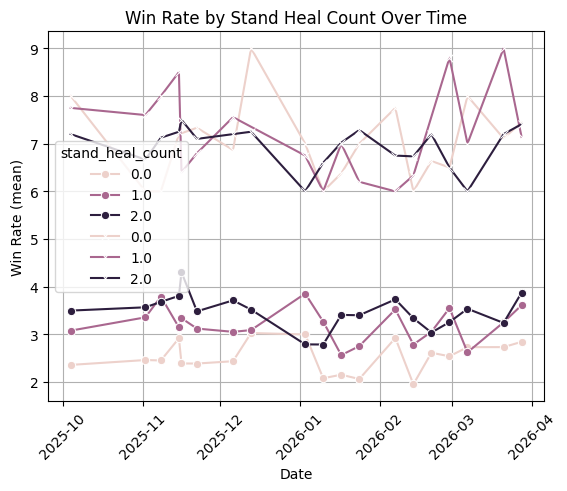

In [32]:
import matplotlib.pyplot as plt
CUTOFF = 3
data = full_df[full_df.stand_heal_count < CUTOFF].groupby(['date','stand_heal_count']).describe().\
    loc[:, (slice(None), ['count', 'mean', 'std'])]
df_plot = data.reset_index()
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot['win_rate'] = df_plot[('wins', 'mean')]

seaborn.lineplot(
    data=df_plot,
    x='date',
    y='win_rate',
    hue='stand_heal_count',
    marker='o'
)

plt.ylabel('Win Rate (mean)')
plt.xlabel('Date')
plt.title('Win Rate by Stand Heal Count Over Time')
plt.xticks(rotation=45)
# plt.tight_layout()
plt.grid()


data2 = top_df[top_df.stand_heal_count < CUTOFF].groupby(['date','stand_heal_count']).describe().\
    loc[:, (slice(None), ['count', 'mean', 'std'])]
df_plot2= data2.reset_index()
df_plot2['date'] = pd.to_datetime(df_plot2.date)
df_plot2['win_rate'] = df_plot2[('wins','mean')]

seaborn.lineplot(
    data=df_plot2,
    x='date',
    y='win_rate',
    hue='stand_heal_count',
    marker='x'
)


In [33]:

# seaborn.lineplot(
#     # data=data, 
#     x=data.index, y=data.wins.mean
# )

Alicia was looking for a specific deck that was playing a different ride line than most decks. 
Let's see if we can find it for her

In [34]:
artisarias = full_df[full_df['boss']=='PolyPhonicOverDrive, Artisaria']

artisarias.loc[:,'flag'] = artisarias.deck.apply(
    lambda deck: card_is_in_deck(
        decks_dict=deck, 
        card_name='Expanding World, Wilista', 
        deck='RideDeck'
    )
)
filtered = artisarias[artisarias['flag']==True]
filtered.head()


/var/folders/11/sqv42t4x0qx5nnrnmm9mfm3r0000gn/T/ipykernel_2532/4178425368.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  artisarias.loc[:,'flag'] = artisarias.deck.apply(


,rank,name,boss,wins,nation,decklog,deck,location,region,date,regalis_piece,crit_heal_count,draw_count,stand_heal_count,crit_heals,over_trigger,sheild_draws,shield_fronts,soul_fronts,stand_heals,flag
4457,56,Fareez,"PolyPhonicOverDrive, Artisaria",5,Lyrical Monasterio,27RU7,{'RideDeck': {'DZ-BT07/016EN : PolyPhonicOverD...,Singapore,AO,"January 24, 2026",None,0.0,0.0,2.0,0,Blue,4,0,0,2,True
